# Customer Churn & Retention Intelligence System

## Phase 4 — Model Training and Evaluation

### Objective

The objective of this phase is to train and evaluate customer churn classification models using the customer-level feature dataset.

The modeling workflow is designed to avoid data leakage by fitting all
preprocessing steps only on the training data.

A simple baseline model is evaluated first before moving to more
complex tree-based models.

In [1]:
#  Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

feature_file = (
    PROCESSED_DATA_DIR
    / "customer_features.csv"
)

feature_file

WindowsPath('c:/Users/ptbha/OneDrive/Desktop/customer-churn-retention-intelligence/data/processed/customer_features.csv')

In [3]:
#Load modeling dataset
customer_features = pd.read_csv(
    feature_file
)

print(
    "Dataset shape:",
    customer_features.shape
)

customer_features.head()

Dataset shape: (4979, 18)


,Customer ID,Churn,RecencyDays,PurchaseFrequency,MonetaryValue,AverageOrderValue,CustomerTenureDays,UniqueProducts,AverageQuantityPerOrder,MedianPurchaseGap,MeanPurchaseGap,ReturnTransactionCount,ReturnedQuantity,ReturnedValue,IsRepeatCustomer,ReturnTransactionRate,ProductsPerOrder,PurchaseActivityRate
0,13085,0,114.953472,7,2295.30,327.900000,558.211806,46,128.571429,57.0,147.666667,2.0,109.0,973.82,1,0.285714,6.571429,0.012518
1,13078,0,20.028472,41,20857.28,508.714146,558.155556,131,191.268293,12.0,13.794872,29.0,105.0,576.01,1,0.707317,3.195122,0.073325
2,15362,1,268.092361,2,613.08,306.540000,558.154167,38,184.000000,290.0,290.000000,0.0,0.0,0.00,1,0.000000,19.000000,0.003577
3,18102,0,2.807639,102,413459.37,4053.523235,558.143056,310,1357.745098,7.0,11.100000,7.0,1229.0,7545.83,1,0.068627,3.039216,0.182422
4,12682,0,11.970833,32,15947.69,498.365313,558.140278,251,224.718750,15.0,17.612903,1.0,9.0,88.10,1,0.031250,7.843750,0.057231


In [4]:
#Validate modeling dataset
print(
    "Missing values:",
    customer_features.isna().sum().sum()
)

print(
    "Duplicate customer IDs:",
    customer_features["Customer ID"]
    .duplicated()
    .sum()
)

print("\nChurn distribution:")
print(
    customer_features["Churn"]
    .value_counts()
)

print("\nChurn percentage:")
print(
    customer_features["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Missing values: 0
Duplicate customer IDs: 0

Churn distribution:
Churn
0    2577
1    2402
Name: count, dtype: int64

Churn percentage:
Churn
0    51.76
1    48.24
Name: proportion, dtype: float64


In [5]:
#Define features and target
X = customer_features.drop(
    columns=[
        "Customer ID",
        "Churn"
    ]
)

y = customer_features["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nModel features:")
for feature in X.columns:
    print("-", feature)

Feature matrix shape: (4979, 16)
Target shape: (4979,)

Model features:
- RecencyDays
- PurchaseFrequency
- MonetaryValue
- AverageOrderValue
- CustomerTenureDays
- UniqueProducts
- AverageQuantityPerOrder
- MedianPurchaseGap
- MeanPurchaseGap
- ReturnTransactionCount
- ReturnedQuantity
- ReturnedValue
- IsRepeatCustomer
- ReturnTransactionRate
- ProductsPerOrder
- PurchaseActivityRate


## Train-Test Split

The customer-level dataset is divided into training and test sets.

A stratified split is used so that the churn distribution remains
approximately consistent across both datasets.

The test dataset is kept separate and is not used while fitting
preprocessing steps or training the model.

In [6]:
#Train/test split
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Training rows:",
    X_train.shape[0]
)

print(
    "Test rows:",
    X_test.shape[0]
)

print(
    "\nTraining churn rate:",
    f"{y_train.mean() * 100:.2f}%"
)

print(
    "Test churn rate:",
    f"{y_test.mean() * 100:.2f}%"
)

Training rows: 3983
Test rows: 996

Training churn rate: 48.26%
Test churn rate: 48.19%


## Baseline Model — Logistic Regression

Logistic Regression is used as the initial benchmark model.

Because several numerical features have very different scales,
StandardScaler is included inside a pipeline.

Using a pipeline ensures that scaling parameters are learned only
from the training data.

In [7]:
#Build pipeline
logistic_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logi

In [8]:
#Train baseline
logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed."
)

Logistic Regression training completed.


In [9]:
logistic_predictions = (
    logistic_pipeline.predict(
        X_test
    )
)

logistic_probabilities = (
    logistic_pipeline.predict_proba(
        X_test
    )[:, 1]
)

In [10]:
#Evaluation metrics
logistic_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_predictions
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions
    ),
    "F1 Score": f1_score(
        y_test,
        logistic_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        logistic_probabilities
    )
}

pd.Series(
    logistic_metrics
).round(4)

Accuracy     0.7269
Precision    0.7088
Recall       0.7354
F1 Score     0.7219
ROC-AUC      0.7988
PR-AUC       0.7660
dtype: float64

In [11]:
#Classification report
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Returned",
            "Churned"
        ]
    )
)

              precision    recall  f1-score   support

    Returned       0.74      0.72      0.73       516
     Churned       0.71      0.74      0.72       480

    accuracy                           0.73       996
   macro avg       0.73      0.73      0.73       996
weighted avg       0.73      0.73      0.73       996



In [12]:
#Confusion matrix
conf_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

conf_matrix

array([[371, 145],
       [127, 353]])

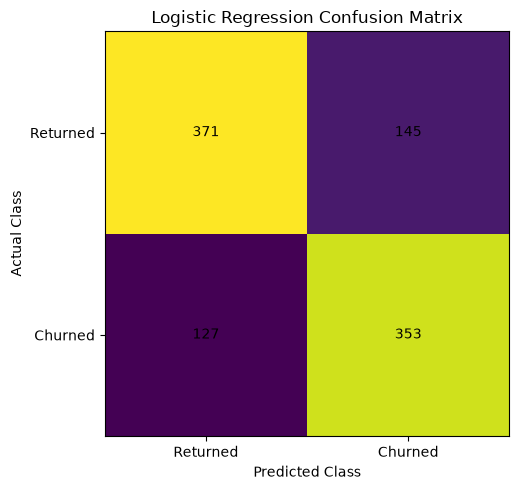

In [13]:
plt.figure(figsize=(6, 5))

plt.imshow(
    conf_matrix
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.xticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.tight_layout()
plt.show()

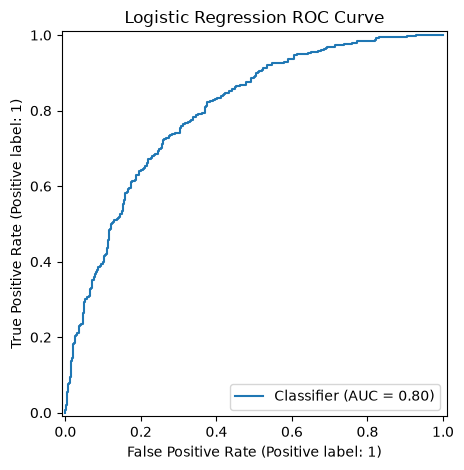

In [14]:
#ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities
)

plt.title(
    "Logistic Regression ROC Curve"
)

plt.tight_layout()
plt.show()

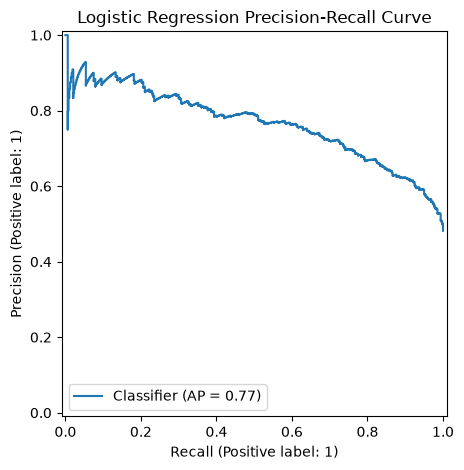

In [15]:
#Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    logistic_probabilities
)

plt.title(
    "Logistic Regression Precision-Recall Curve"
)

plt.tight_layout()
plt.show()

## Model 2 — Random Forest

Random Forest is evaluated as a nonlinear ensemble model.

Unlike Logistic Regression, Random Forest can capture interactions and
nonlinear relationships between customer behavioural features without
requiring feature scaling.

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
#Train Random Forest
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [18]:
rf_predictions = random_forest.predict(
    X_test
)

rf_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]

In [19]:
rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        rf_predictions
    ),
    "Precision": precision_score(
        y_test,
        rf_predictions
    ),
    "Recall": recall_score(
        y_test,
        rf_predictions
    ),
    "F1 Score": f1_score(
        y_test,
        rf_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        rf_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        rf_probabilities
    )
}

pd.Series(
    rf_metrics
).round(4)

Accuracy     0.7118
Precision    0.6918
Recall       0.7250
F1 Score     0.7080
ROC-AUC      0.7928
PR-AUC       0.7542
dtype: float64

In [20]:
#Classification report
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Returned",
            "Churned"
        ]
    )
)

              precision    recall  f1-score   support

    Returned       0.73      0.70      0.72       516
     Churned       0.69      0.72      0.71       480

    accuracy                           0.71       996
   macro avg       0.71      0.71      0.71       996
weighted avg       0.71      0.71      0.71       996



In [21]:
#Confusion matrix
rf_conf_matrix = confusion_matrix(
    y_test,
    rf_predictions
)

rf_conf_matrix

array([[361, 155],
       [132, 348]])

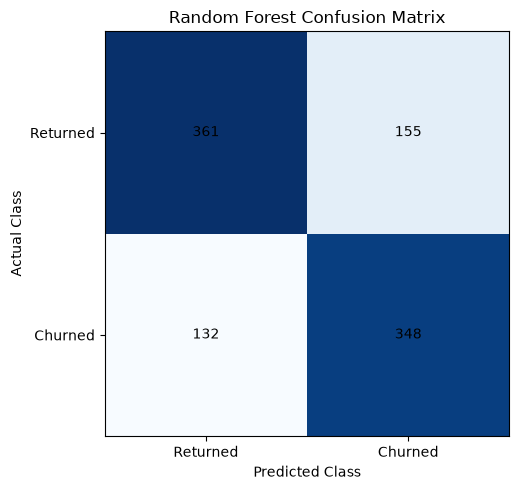

In [22]:
plt.figure(figsize=(6, 5))

plt.imshow(
    rf_conf_matrix,
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(rf_conf_matrix.shape[0]):
    for j in range(rf_conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            rf_conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.xticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.tight_layout()
plt.show()

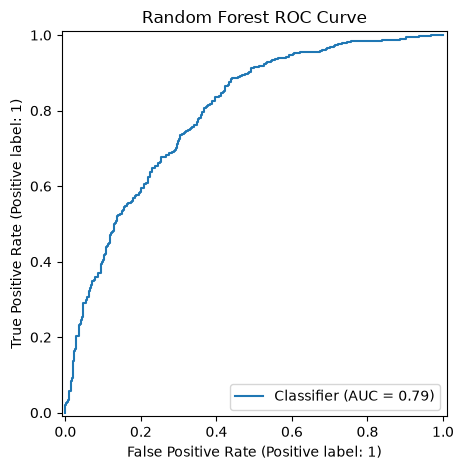

In [23]:
#ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities
)

plt.title(
    "Random Forest ROC Curve"
)

plt.tight_layout()
plt.show()

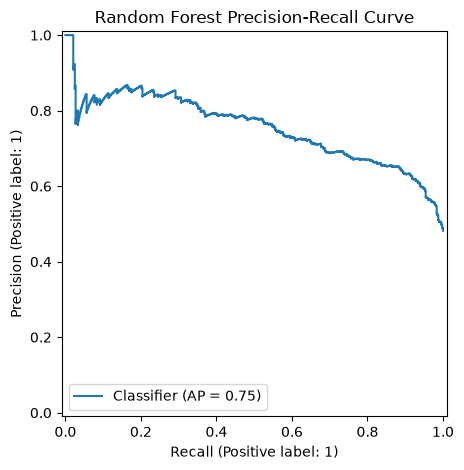

In [24]:
#Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_probabilities
)

plt.title(
    "Random Forest Precision-Recall Curve"
)

plt.tight_layout()
plt.show()

In [25]:
#Compare baseline vs Random Fores
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Random Forest": rf_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Logistic Regression,0.7269,0.7088,0.7354,0.7219,0.7988,0.7660
Random Forest,0.7118,0.6918,0.7250,0.7080,0.7928,0.7542


## Model 3 — XGBoost

XGBoost is evaluated as a gradient-boosted tree model.

It can capture nonlinear feature relationships and interactions while
providing strong performance on structured tabular data.

The initial model is trained with moderate regularisation before any
hyperparameter tuning is performed.

In [26]:
from xgboost import XGBClassifier

In [27]:
#Train initial XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [28]:
xgb_predictions = xgb_model.predict(
    X_test
)

xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:, 1]

In [29]:
xgb_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        xgb_predictions
    ),
    "Precision": precision_score(
        y_test,
        xgb_predictions
    ),
    "Recall": recall_score(
        y_test,
        xgb_predictions
    ),
    "F1 Score": f1_score(
        y_test,
        xgb_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        xgb_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        xgb_probabilities
    )
}

pd.Series(
    xgb_metrics
).round(4)

Accuracy     0.7199
Precision    0.6982
Recall       0.7375
F1 Score     0.7173
ROC-AUC      0.7931
PR-AUC       0.7493
dtype: float64

In [30]:
print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=[
            "Returned",
            "Churned"
        ]
    )
)

              precision    recall  f1-score   support

    Returned       0.74      0.70      0.72       516
     Churned       0.70      0.74      0.72       480

    accuracy                           0.72       996
   macro avg       0.72      0.72      0.72       996
weighted avg       0.72      0.72      0.72       996



In [31]:
xgb_conf_matrix = confusion_matrix(
    y_test,
    xgb_predictions
)

xgb_conf_matrix

array([[363, 153],
       [126, 354]])

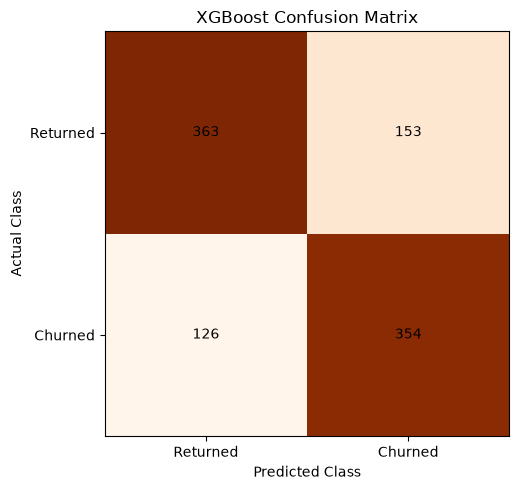

In [32]:
plt.figure(figsize=(6, 5))

plt.imshow(
    xgb_conf_matrix,
    cmap="Oranges"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(xgb_conf_matrix.shape[0]):
    for j in range(xgb_conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            xgb_conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.xticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.tight_layout()
plt.show()

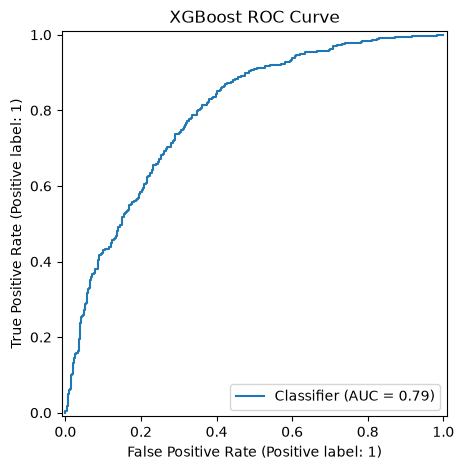

In [33]:
#ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    xgb_probabilities
)

plt.title(
    "XGBoost ROC Curve"
)

plt.tight_layout()
plt.show()

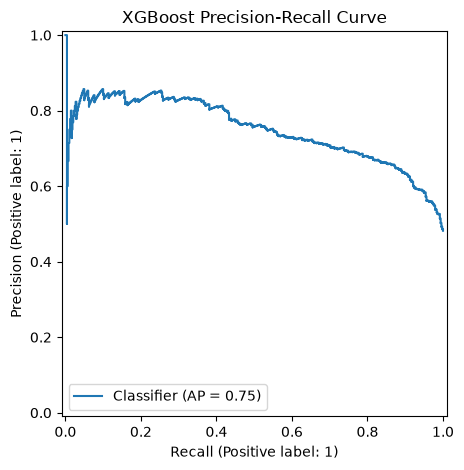

In [34]:
#Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_probabilities
)

plt.title(
    "XGBoost Precision-Recall Curve"
)

plt.tight_layout()
plt.show()

In [35]:
#Compare all three models
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Random Forest": rf_metrics,
        "XGBoost": xgb_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Logistic Regression,0.7269,0.7088,0.7354,0.7219,0.7988,0.7660
Random Forest,0.7118,0.6918,0.7250,0.7080,0.7928,0.7542
XGBoost,0.7199,0.6982,0.7375,0.7173,0.7931,0.7493


## XGBoost Hyperparameter Tuning

The initial XGBoost model achieved competitive churn recall but did not
outperform Logistic Regression across the overall evaluation metrics.

A focused hyperparameter search is therefore performed to determine whether
the boosted-tree model can improve its ability to rank churn-risk customers
while maintaining reasonable classification performance.

ROC-AUC is used as the primary tuning metric because the final system will
use predicted probabilities for customer risk ranking.

In [36]:
#Parameter search
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [150, 250, 350, 450],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.02, 0.05, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function 

In [37]:
print("Best parameters:")
print(xgb_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    round(xgb_search.best_score_, 4)
)

Best parameters:
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 350, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.7}

Best cross-validation ROC-AUC: 0.8165


In [38]:
#Evaluate tuned XGBoost
xgb_tuned = xgb_search.best_estimator_

xgb_tuned_predictions = xgb_tuned.predict(X_test)

xgb_tuned_probabilities = xgb_tuned.predict_proba(
    X_test
)[:, 1]

xgb_tuned_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        xgb_tuned_predictions
    ),
    "Precision": precision_score(
        y_test,
        xgb_tuned_predictions
    ),
    "Recall": recall_score(
        y_test,
        xgb_tuned_predictions
    ),
    "F1 Score": f1_score(
        y_test,
        xgb_tuned_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        xgb_tuned_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        xgb_tuned_probabilities
    )
}

pd.Series(
    xgb_tuned_metrics
).round(4)

Accuracy     0.7309
Precision    0.7031
Recall       0.7646
F1 Score     0.7325
ROC-AUC      0.8029
PR-AUC       0.7677
dtype: float64

In [39]:
#Classification report + confusion matrix
print(
    classification_report(
        y_test,
        xgb_tuned_predictions,
        target_names=[
            "Returned",
            "Churned"
        ]
    )
)

xgb_tuned_conf_matrix = confusion_matrix(
    y_test,
    xgb_tuned_predictions
)

xgb_tuned_conf_matrix

              precision    recall  f1-score   support

    Returned       0.76      0.70      0.73       516
     Churned       0.70      0.76      0.73       480

    accuracy                           0.73       996
   macro avg       0.73      0.73      0.73       996
weighted avg       0.73      0.73      0.73       996



array([[361, 155],
       [113, 367]])

In [40]:
#Final model comparison
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Random Forest": rf_metrics,
        "XGBoost": xgb_metrics,
        "Tuned XGBoost": xgb_tuned_metrics
    }
).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Logistic Regression,0.7269,0.7088,0.7354,0.7219,0.7988,0.7660
Random Forest,0.7118,0.6918,0.7250,0.7080,0.7928,0.7542
XGBoost,0.7199,0.6982,0.7375,0.7173,0.7931,0.7493
Tuned XGBoost,0.7309,0.7031,0.7646,0.7325,0.8029,0.7677


## Final Model Selection

Four classification approaches were evaluated:

- Logistic Regression
- Random Forest
- XGBoost
- Tuned XGBoost

The tuned XGBoost model achieved the strongest overall performance,
with the highest Accuracy, Recall, F1 Score, ROC-AUC, and PR-AUC among
the evaluated models.

The model achieved a churn recall of 76.46%, meaning that it correctly
identified more than three-quarters of the churned customers in the
held-out test set.

Tuned XGBoost is therefore selected as the final model for churn-risk
prediction and subsequent explainability analysis.

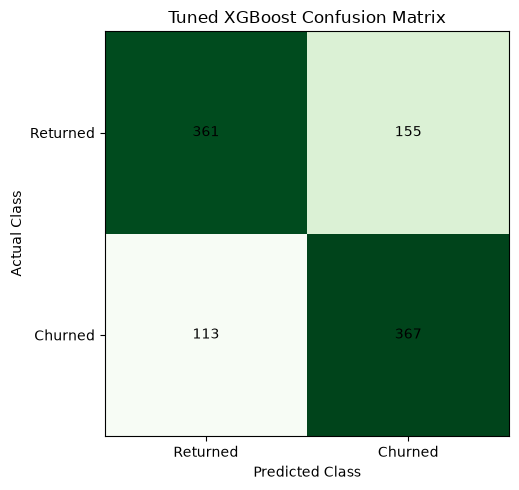

In [41]:
#final confusion matrix
tuned_conf_matrix = confusion_matrix(
    y_test,
    xgb_tuned_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(
    tuned_conf_matrix,
    cmap="Greens"
)

plt.title(
    "Tuned XGBoost Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(tuned_conf_matrix.shape[0]):
    for j in range(tuned_conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            tuned_conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.xticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Returned", "Churned"]
)

plt.tight_layout()
plt.show()

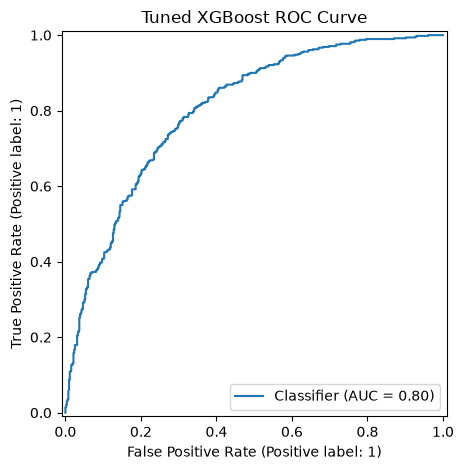

In [42]:
#Final ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    xgb_tuned_probabilities
)

plt.title(
    "Tuned XGBoost ROC Curve"
)

plt.tight_layout()
plt.show()

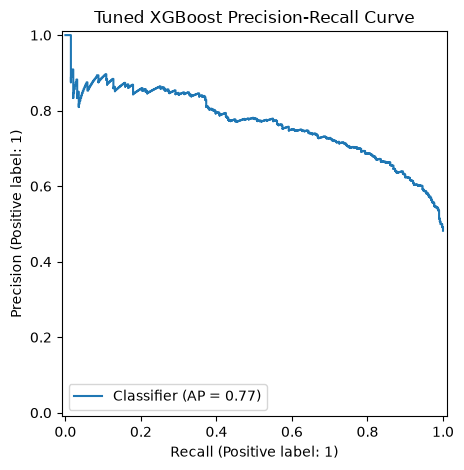

In [43]:
#Final Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_tuned_probabilities
)

plt.title(
    "Tuned XGBoost Precision-Recall Curve"
)

plt.tight_layout()
plt.show()

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_tuned.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,PurchaseFrequency,0.176426
1,PurchaseActivityRate,0.145442
2,RecencyDays,0.142638
3,MonetaryValue,0.105598
4,IsRepeatCustomer,0.092827
5,UniqueProducts,0.065060
6,MeanPurchaseGap,0.052731
7,MedianPurchaseGap,0.032084
8,AverageQuantityPerOrder,0.027666
9,ReturnedValue,0.025267


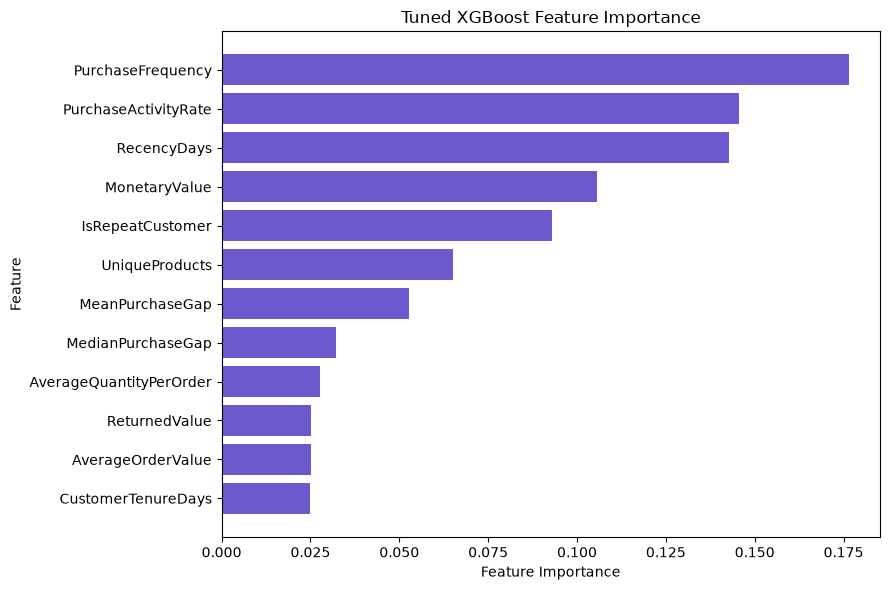

In [45]:
#Plot feature importance
top_features = feature_importance.head(12)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="slateblue"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Tuned XGBoost Feature Importance"
)

plt.tight_layout()
plt.show()

In [46]:
model_comparison.to_csv(
    PROCESSED_DATA_DIR
    / "model_comparison.csv"
)

print(
    "Model comparison saved successfully."
)

Model comparison saved successfully.


In [47]:
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR

WindowsPath('c:/Users/ptbha/OneDrive/Desktop/customer-churn-retention-intelligence/models')

In [48]:
import joblib

model_file = (
    MODEL_DIR
    / "tuned_xgboost_churn_model.joblib"
)

joblib.dump(
    xgb_tuned,
    model_file
)

print(
    "Final model saved:",
    model_file
)

Final model saved: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\models\tuned_xgboost_churn_model.joblib


In [49]:
feature_names = pd.DataFrame({
    "Feature": X_train.columns
})

feature_names.to_csv(
    MODEL_DIR
    / "model_features.csv",
    index=False
)

print(
    "Model feature list saved."
)

Model feature list saved.


In [50]:
loaded_model = joblib.load(
    model_file
)

verification_predictions = (
    loaded_model.predict(X_test)
)

print(
    "Saved model verification:",
    np.array_equal(
        verification_predictions,
        xgb_tuned_predictions
    )
)

Saved model verification: True


## Summary

Logistic Regression, Random Forest, and XGBoost models were trained and
evaluated using a stratified held-out test dataset.

Logistic Regression provided a strong baseline with a ROC-AUC of 0.7988.

The initial Random Forest and XGBoost models did not outperform the
baseline across the overall evaluation metrics.

XGBoost was subsequently tuned using five-fold cross-validation and a
focused randomized hyperparameter search.

The tuned XGBoost model achieved:

- Accuracy: 73.09%
- Precision: 70.31%
- Recall: 76.46%
- F1 Score: 73.25%
- ROC-AUC: 0.8029
- PR-AUC: 0.7677

The tuned XGBoost model was selected as the final churn prediction model
because it achieved the strongest overall evaluation performance and the
highest churn recall.

The trained model and model feature list were saved for subsequent
explainability and deployment phases.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Output folder
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# Load model comparison results

model_df = pd.read_csv("../data/processed/model_comparison.csv")

print("Model comparison columns:")
print(model_df.columns.tolist())

model_df

Model comparison columns:
['Unnamed: 0', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC']


,Unnamed: 0,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.726908,0.708835,0.735417,0.721881,0.798813,0.766050
1,Random Forest,0.711847,0.691849,0.725000,0.708037,0.792829,0.754162
2,XGBoost,0.719880,0.698225,0.737500,0.717325,0.793148,0.749284
3,Tuned XGBoost,0.730924,0.703065,0.764583,0.732535,0.802877,0.767704


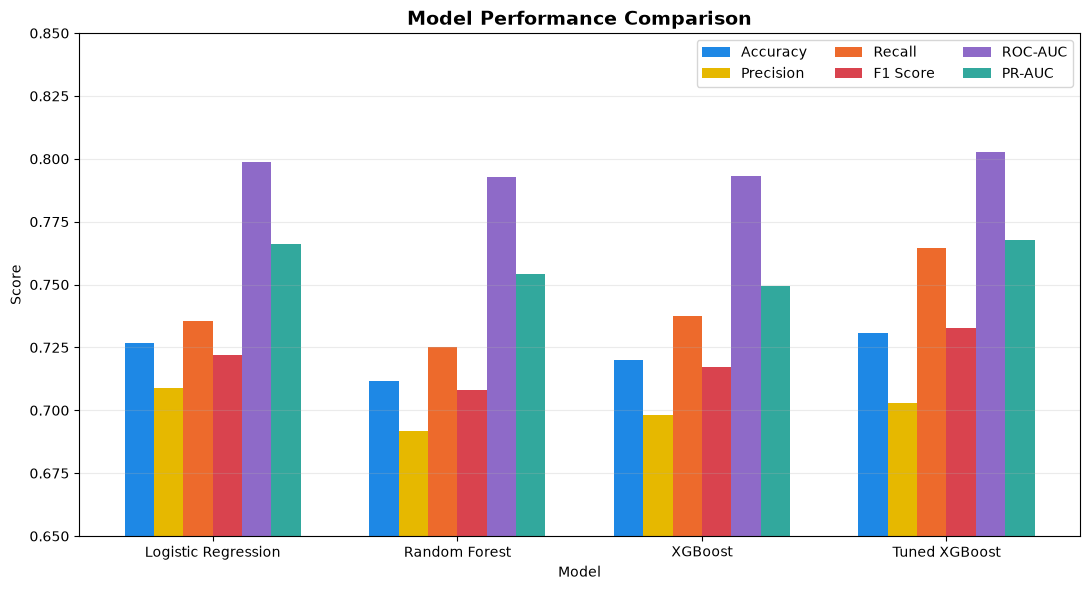

Saved: reports/figures/04_model_comparison.png


In [3]:
# Figure 4: Model Comparison

model_plot_df = model_df.rename(columns={"Unnamed: 0": "Model"})

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]

x = range(len(model_plot_df))

plt.figure(figsize=(11, 6))

bar_width = 0.12

colors = [
    "#1E88E5",
    "#E6B800",
    "#ED6A2C",
    "#D9434E",
    "#8E6AC8",
    "#32A89D"
]

for i, metric in enumerate(metrics):
    plt.bar(
        [pos + i * bar_width for pos in x],
        model_plot_df[metric],
        width=bar_width,
        label=metric,
        color=colors[i]
    )

plt.xticks(
    [pos + bar_width * 2.5 for pos in x],
    model_plot_df["Model"]
)

plt.ylim(0.65, 0.85)

plt.title(
    "Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(ncol=3)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "04_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: reports/figures/04_model_comparison.png")